# Modeling notebook

# KNN Test
- first do the quick EDA 
- then do the model building
- then do the model evaluation
- then do the model deployment
- then do the model monitoring
- then do the model deployment

**First, import all the necessary libraries required**

In [166]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


In [167]:
df = pd.read_csv("../data/processed/final_spotify.csv")
print("Dataset loaded with shape:", df.shape)
df.head()

Dataset loaded with shape: (2727, 27)


,Track,Artist,Genre,Release Date,All Time Rank,Spotify Streams,Spotify Popularity,YouTube Views,TikTok Views,AirPlay Spins,...,Energy,Instrumentalness,Key,Liveness,Loudness,Mode,Speechiness,Tempo,Time_signature,Valence
0,Million Dollar Baby,Tommy Richman,Latin,4/26/2024,1,390470936,92,84274754,5332281936,40975,...,0.697,0.000370,1.0,0.0678,-5.520,0.0,0.0439,138.029,4.0,0.919
1,Not Like Us,Kendrick Lamar,R&B/Soul,5/4/2024,2,323703884,92,116347040,208339025,40778,...,0.472,0.000000,1.0,0.1410,-7.001,1.0,0.0776,101.061,4.0,0.214
2,I Like The Way You Kiss Me,Artemas,Pop,3/19/2024,3,601309283,92,122599116,3369120610,74333,...,0.946,0.010600,11.0,0.0826,-4.263,1.0,0.0447,151.647,4.0,0.747
3,Flowers,Miley Cyrus,Pop,1/12/2023,4,2031280633,85,1096100899,14603725994,1474799,...,0.691,0.000070,0.0,0.0232,-4.775,1.0,0.0633,118.048,4.0,0.632
4,Lovin On Me,Jack Harlow,Latin,11/10/2023,6,670665438,83,131148091,2938686633,522042,...,0.558,0.000002,2.0,0.0937,-4.911,1.0,0.0568,104.983,4.0,0.606


In [168]:
# Create artist popularity feature

df["artist_track_count"] = df.groupby("Artist")["Track"].transform("count")
df.shape

(2727, 28)

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2727 entries, 0 to 2726
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Track               2727 non-null   object 
 1   Artist              2727 non-null   object 
 2   Genre               2727 non-null   object 
 3   Release Date        2727 non-null   object 
 4   All Time Rank       2727 non-null   int64  
 5   Spotify Streams     2727 non-null   int64  
 6   Spotify Popularity  2727 non-null   int64  
 7   YouTube Views       2727 non-null   int64  
 8   TikTok Views        2727 non-null   int64  
 9   AirPlay Spins       2727 non-null   int64  
 10  Shazam Counts       2727 non-null   int64  
 11  Explicit Track      2727 non-null   int64  
 12  Isrc                2727 non-null   object 
 13  Spotify_id          2727 non-null   object 
 14  Acousticness        2727 non-null   float64
 15  Danceability        2727 non-null   float64
 16  Durati

In [170]:
# Create target: top 25% Spotify Popularity = popular
threshold= df["Spotify Popularity"].quantile(0.70)
df["is_popular"] = (df["Spotify Popularity"] >= threshold).astype(int)
print(f"Popular: {df['is_popular'].sum()} | Not popular: {(df['is_popular'] == 0).sum()}")


Popular: 874 | Not popular: 1853


**Quick EDA**

In [171]:
#sns.pairplot(df, hue="Spotify Popularity")
#plt.show()

In [172]:
#sns.pairplot(df, hue="Genre")
#plt.show()

**Select features and split**   

In [173]:
le = LabelEncoder()
df["Genre"] = le.fit_transform(df["Genre"])

In [174]:
feature_cols = [
    # Audio features
    "Danceability", "Energy", "Loudness", "Speechiness",
    "Acousticness", "Instrumentalness", "Liveness",
    "Valence", "Tempo", "Duration_ms", "Key", "Mode", "Time_signature","Genre",
    # Platform features (NOT from Spotify — avoids leakage)
    "YouTube Views", "TikTok Views", "Shazam Counts", "AirPlay Spins"
]

In [175]:
# Drop rows with missing values in these columns
df_ = df[feature_cols + ["is_popular"]].dropna()
print(f"Rows after cleaning: {len(df_)}")

X = df_[feature_cols]
y = df_["is_popular"]
# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")


Rows after cleaning: 2727
Train: 2181 | Test: 546


**Scale the features**

In [176]:
# KNN NEEDS scaling — otherwise big numbers (YouTube Views: millions)
# dominate small numbers (danceability: 0-1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Find the best K**

K=3: accuracy = 0.678
K=5: accuracy = 0.705
K=7: accuracy = 0.707
K=9: accuracy = 0.718
K=11: accuracy = 0.714
K=13: accuracy = 0.720
K=15: accuracy = 0.714
K=17: accuracy = 0.718
K=19: accuracy = 0.718
K=21: accuracy = 0.725


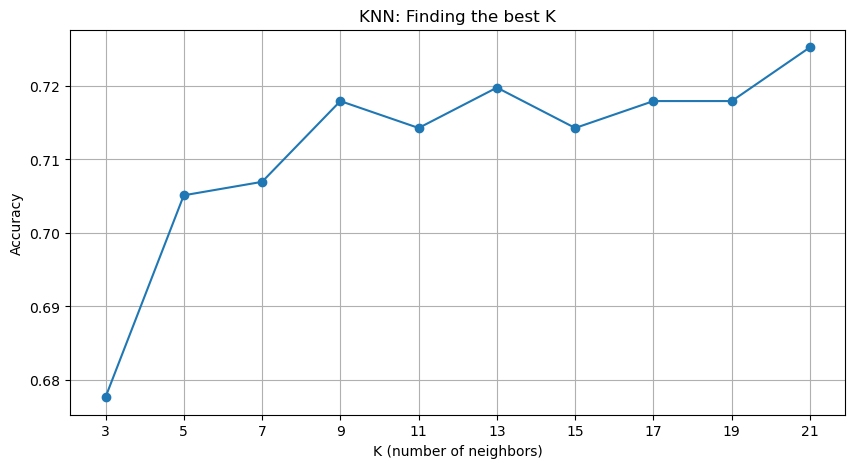

In [177]:
k_values = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    score = accuracy_score(y_test, knn.predict(X_test_scaled))
    scores.append(score)
    print(f"K={k}: accuracy = {score:.3f}")

# Plot to visualize
plt.figure(figsize=(10, 5))
plt.plot(k_values, scores, marker="o")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN: Finding the best K")
plt.xticks(k_values)
plt.grid(True)
plt.show()



In [178]:
# Best K
best_k = k_values[scores.index(max(scores))]
print(f"\nBest K = {best_k} with accuracy = {max(scores):.3f}")



Best K = 21 with accuracy = 0.725


**Train the model with best K**

In [179]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred = knn_final.predict(X_test_scaled)


In [180]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Popular", "Popular"]))


Accuracy: 0.725

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.74      0.94      0.82       374
     Popular       0.66      0.27      0.38       172

    accuracy                           0.73       546
   macro avg       0.70      0.60      0.60       546
weighted avg       0.71      0.73      0.68       546



**Confusion Matrix**

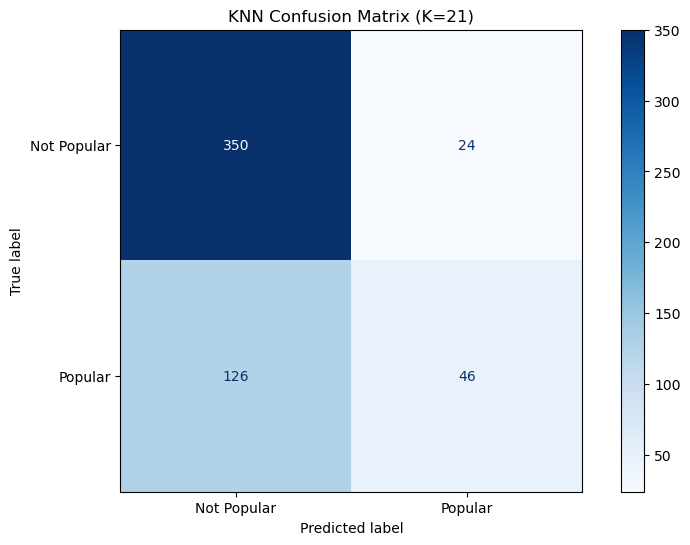

In [181]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 6))
ConfusionMatrixDisplay.from_estimator(
    knn_final, X_test_scaled, y_test,
    display_labels=["Not Popular", "Popular"],
    cmap="Blues", ax=ax
)
plt.title(f"KNN Confusion Matrix (K={best_k})")
plt.show()


**Test with a real song**

In [183]:
def predict_popularity(song_name):
    song = df[df["Track"] == song_name]
    
    if len(song) == 0:
        print(f"Song '{song_name}' not found")
        return
    
    song_features = song[feature_cols].iloc[0:1]
    song_scaled = scaler.transform(song_features)
    
    prediction = knn_final.predict(song_scaled)[0]
    neighbors = knn_final.kneighbors(song_scaled)
    
    result = "POPULAR" if prediction == 1 else "NOT POPULAR"
    print(f"{song_name} by {song['Artist'].values[0]}")
    print(f"Prediction: {result}")
    print(f"Spotify Popularity (actual): {song['Spotify Popularity'].values[0]}")

# Test it
predict_popularity("Aashiq Awaara")


Aashiq Awaara by Badshah
Prediction: NOT POPULAR
Spotify Popularity (actual): 27


In [184]:
df.tail()

,Track,Artist,Genre,Release Date,All Time Rank,Spotify Streams,Spotify Popularity,YouTube Views,TikTok Views,AirPlay Spins,...,Key,Liveness,Loudness,Mode,Speechiness,Tempo,Time_signature,Valence,artist_track_count,is_popular
2722,Aashiq Awaara,Badshah,5,8/17/2018,4056,2574126,27,1033803791,2785871,150,...,0.0,0.0935,-6.426,0.0,0.0845,99.971,4.0,0.9630,5,0
2723,Baby Said,MÃÂ¯ÃÂ¿ÃÂ½ÃÂ¯ÃÂ¿ÃÂ½ne,6,1/20/2023,4057,166942258,71,23143608,39481015,62922,...,6.0,0.0796,-4.040,0.0,0.0323,131.012,4.0,0.6070,7,0
2724,Gangstas,Pop Smoke,3,7/3/2020,4065,234889039,62,121584355,118304933,224,...,4.0,0.0788,-7.434,0.0,0.1020,119.987,5.0,0.5570,11,0
2725,Too Good,Drake,6,4/29/2016,4074,1052473730,68,10990620,308797315,28897,...,7.0,0.1000,-7.839,1.0,0.1040,117.996,4.0,0.3970,35,0
2726,Alone,Rod Wave,6,8/9/2022,4098,64562541,55,63051891,38123007,1310,...,3.0,0.0811,-6.911,0.0,0.0368,82.070,4.0,0.0923,10,0


How to read the results:

The classification report gives you:
- Precision for "Popular": when the model says popular, how often is it right?
- Recall for "Popular": of all actually popular songs, how many did it catch?
- F1 score: the balance between precision and recall
- Accuracy: overall percentage correct

The confusion matrix shows:
- Top left: correctly predicted "not popular" ✓
- Top right: predicted "popular" but was actually not (false positive)
- Bottom left: predicted "not popular" but was actually popular (false negative)
- Bottom right: correctly predicted "popular" ✓


# HYPERPARAMETER TUNING - KNN 


**GridSearch for KNN**

In [185]:
from sklearn.model_selection import GridSearchCV


In [186]:
# Define what hyperparameters to test
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],    # how many neighbors
    "weights": ["uniform", "distance"],            # uniform = all neighbors vote equally
                                                   # distance = closer neighbors count more
    "metric": ["euclidean", "cosine"]              # how to measure distance
}

# Run the search
grid_knn = GridSearchCV(
    KNeighborsClassifier(),     # the model
    param_grid_knn,             # all combinations to test
    cv=5,                       # 5-fold cross-validation
    scoring="f1",               # optimize for F1 score (not just accuracy)
    n_jobs=-1                   # use all CPU cores (faster)
)

grid_knn.fit(X_train_scaled, y_train)

# Results
print(f"Best parameters: {grid_knn.best_params_}")
print(f"Best F1 score (cross-validated): {grid_knn.best_score_:.3f}")

# Use the best model
best_knn = grid_knn.best_estimator_
y_pred_best_knn = best_knn.predict(X_test_scaled)
print(f"Test accuracy: {accuracy_score(y_test, y_pred_best_knn):.3f}")


Best parameters: {'metric': 'cosine', 'n_neighbors': 3, 'weights': 'uniform'}
Best F1 score (cross-validated): 0.466
Test accuracy: 0.689


# RANDOM FOREST

Random Forest is an ensemble of decision trees. Unlike KNN:
- It handles raw (unscaled) features well
- Gives feature importance scores
- Tends to be more robust to outliers and noise

**Import Random Forest libraries**

In [187]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

**Train a baseline Random Forest**

We reuse the same `X_train`, `X_test`, `y_train`, `y_test` from the KNN section.
Random Forest does NOT require scaling, so we use the original (unscaled) splits.

In [188]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
y_pred_rf = rf_base.predict(X_test)

print(f"Baseline Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Not Popular", "Popular"]))

Baseline Random Forest Accuracy: 0.740

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.75      0.93      0.83       374
     Popular       0.67      0.34      0.45       172

    accuracy                           0.74       546
   macro avg       0.71      0.63      0.64       546
weighted avg       0.73      0.74      0.71       546



**Confusion Matrix**

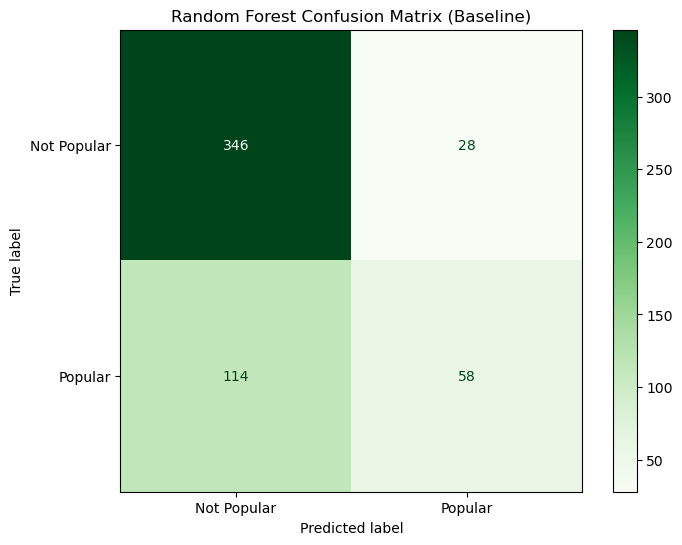

In [189]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    rf_base, X_test, y_test,
    display_labels=["Not Popular", "Popular"],
    cmap="Greens", ax=ax
)
plt.title("Random Forest Confusion Matrix (Baseline)")
plt.show()

**Feature Importance**

One of Random Forest's big advantages: it tells you *which features* drove the predictions.

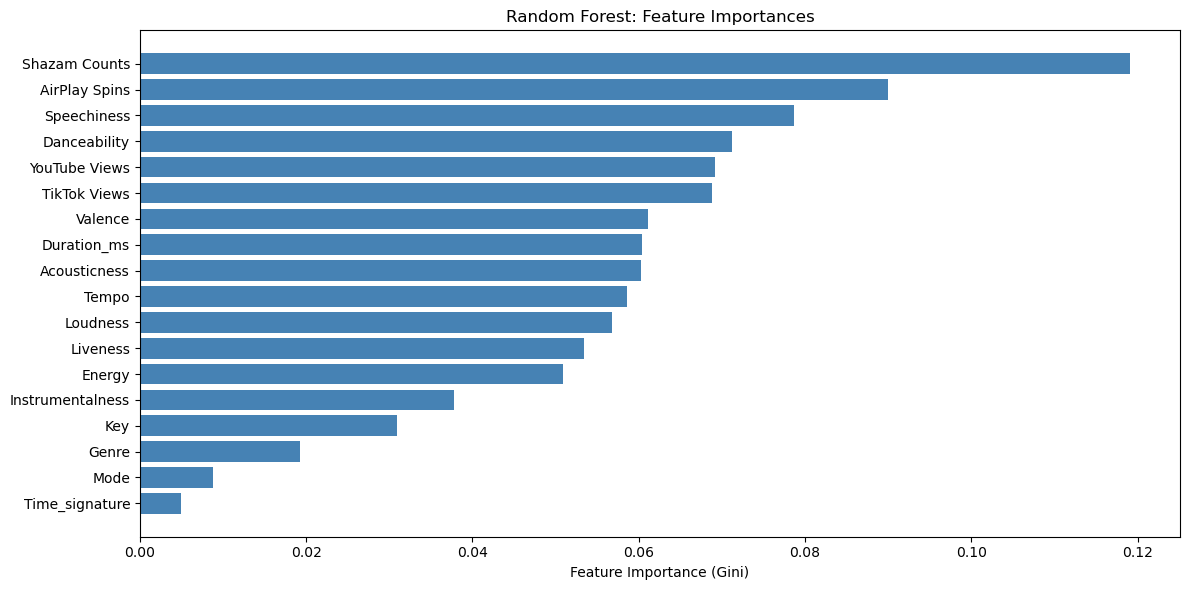

         Feature  Importance
   Shazam Counts    0.119127
   AirPlay Spins    0.089913
     Speechiness    0.078664
    Danceability    0.071267
   YouTube Views    0.069138
    TikTok Views    0.068753
         Valence    0.061161
     Duration_ms    0.060387
    Acousticness    0.060290
           Tempo    0.058535
        Loudness    0.056815
        Liveness    0.053377
          Energy    0.050866
Instrumentalness    0.037745
             Key    0.030906
           Genre    0.019314
            Mode    0.008826
  Time_signature    0.004916


In [190]:
importances = rf_base.feature_importances_
feat_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(feat_df["Feature"][::-1], feat_df["Importance"][::-1], color="steelblue")
plt.xlabel("Feature Importance (Gini)")
plt.title("Random Forest: Feature Importances")
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))

**Overfitting check**

In [191]:
# Rule of thumb:
#   Gap < 0.05 → excellent
#   Gap 0.05-0.10 → acceptable
#   Gap > 0.10 → overfitting, needs tuning

train_acc_rf = accuracy_score(y_train, rf_base.predict(X_train_scaled))
test_acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Train accuracy: {train_acc_rf:.3f}")
print(f"Test accuracy:  {test_acc_rf:.3f}")
print(f"Gap:            {train_acc_rf - test_acc_rf:.3f}")

if train_acc_rf - test_acc_rf > 0.10:
    print("Possible overfitting — tuning should help")
else:
    print("No major overfitting")


Train accuracy: 0.509
Test accuracy:  0.740
Gap:            -0.231
No major overfitting


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# HYPERPARAMETER TUNING - RANDOM FOREST

**GridSearch for Random Forest**

In [192]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],        # number of trees
    "max_depth": [None, 10, 20],             # how deep each tree can grow
    "min_samples_split": [2, 5],             # min samples needed to split a node
    "max_features": ["sqrt", "log2"]        # features considered at each split
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print(f"Best parameters: {grid_rf.best_params_}")
print(f"Best F1 score (cross-validated): {grid_rf.best_score_:.3f}")

best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred_best_rf):.3f}")

Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best F1 score (cross-validated): 0.484
Test accuracy: 0.740


**Test with a real song**

In [193]:
def predict_popularity_rf(song_name):
    song = df[df["Track"] == song_name]

    if len(song) == 0:
        print(f"Song '{song_name}' not found")
        return

    song_features = song[feature_cols].iloc[0:1]

    # Random Forest does not need scaling
    prediction = best_rf.predict(song_features)[0]
    proba = best_rf.predict_proba(song_features)[0]

    result = "POPULAR" if prediction == 1 else "NOT POPULAR"
    print(f"{song_name} by {song['Artist'].values[0]}")
    print(f"Prediction: {result}")
    print(f"Confidence: Popular={proba[1]:.2f} | Not Popular={proba[0]:.2f}")
    print(f"Spotify Popularity (actual): {song['Spotify Popularity'].values[0]}")

predict_popularity_rf("Aashiq Awaara")

Aashiq Awaara by Badshah
Prediction: NOT POPULAR
Confidence: Popular=0.41 | Not Popular=0.59
Spotify Popularity (actual): 27


# DECISION TREE

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, accuracy_score, ConfusionMatrixDisplay, f1_score)
from xgboost import XGBClassifier

- Loading the data

In [195]:
df = pd.read_csv("../data/processed/final_spotify.csv", encoding='latin-1')
df.head(3)

,Track,Artist,Genre,Release Date,All Time Rank,Spotify Streams,Spotify Popularity,YouTube Views,TikTok Views,AirPlay Spins,...,Energy,Instrumentalness,Key,Liveness,Loudness,Mode,Speechiness,Tempo,Time_signature,Valence
0,Million Dollar Baby,Tommy Richman,Latin,4/26/2024,1,390470936,92,84274754,5332281936,40975,...,0.697,0.00037,1.0,0.0678,-5.520,0.0,0.0439,138.029,4.0,0.919
1,Not Like Us,Kendrick Lamar,R&B/Soul,5/4/2024,2,323703884,92,116347040,208339025,40778,...,0.472,0.00000,1.0,0.1410,-7.001,1.0,0.0776,101.061,4.0,0.214
2,I Like The Way You Kiss Me,Artemas,Pop,3/19/2024,3,601309283,92,122599116,3369120610,74333,...,0.946,0.01060,11.0,0.0826,-4.263,1.0,0.0447,151.647,4.0,0.747


In [196]:
# Create artist popularity feature
df["artist_track_count"] = df.groupby("Artist")["Track"].transform("count")

# Create target: top 25% Spotify Popularity = popular
threshold = df["Spotify Popularity"].quantile(0.75)
df["is_popular"] = (df["Spotify Popularity"] >= threshold).astype(int)

# Check the balance
print("Target distribution:")
print(df["is_popular"].value_counts())
print(f"\nThreshold: Spotify Popularity >= {threshold} = Popular")

Target distribution:
is_popular
0    1957
1     770
Name: count, dtype: int64

Threshold: Spotify Popularity >= 73.0 = Popular


In [197]:
le = LabelEncoder()
df["Genre"] = le.fit_transform(df["Genre"])

In [198]:
feature_cols = [
    # Audio features
    "Danceability", "Energy", "Loudness", "Speechiness",
    "Acousticness", "Instrumentalness", "Liveness",
    "Valence", "Tempo", "Duration_ms", "Key", "Mode", "Time_signature","Genre",
    # Platform features (NOT from Spotify — avoids leakage)
    "YouTube Views", "TikTok Views", "Shazam Counts", "AirPlay Spins"
]

In [199]:
# Drop rows with missing values in our features
df_clean = df[feature_cols + ["is_popular"]].dropna()
print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")
print(f"Rows dropped: {len(df) - len(df_clean)}")

Rows before cleaning: 2727
Rows after cleaning: 2727
Rows dropped: 0


In [200]:
dt = DecisionTreeClassifier(
    max_depth=4,        # limit to 4 levels of questions
    random_state=42     # makes results reproducible (same result every time)
)

In [201]:
X = df_clean[feature_cols]
y = df_clean["is_popular"]

# 80% for training, 20% for testing
# random_state=42 ensures same split every time you run
# stratify=y ensures both sets have same proportion of popular/not popular
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Training set: {len(X_train)} songs")
print(f"Test set: {len(X_test)} songs")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())

Training set: 2181 songs
Test set: 546 songs

Training target distribution:
is_popular
0    1565
1     616
Name: count, dtype: int64

Test target distribution:
is_popular
0    392
1    154
Name: count, dtype: int64


In [202]:
scaler = StandardScaler()

In [203]:
X_train_scaled = scaler.fit_transform(X_train)

In [204]:
X_test_scaled = scaler.transform(X_test)

In [205]:
print("Scaling done!")
print(f"Example — before: YouTube Views mean = {X_train['YouTube Views'].mean():.0f}")
print(f"Example — after: YouTube Views mean = {X_train_scaled[:, feature_cols.index('YouTube Views')].mean():.2f}")

Scaling done!
Example — before: YouTube Views mean = 474523382
Example — after: YouTube Views mean = 0.00


In [206]:
dt_default = DecisionTreeClassifier(
    max_depth=4,        # 4 levels of questions
    random_state=42     # reproducible results
)

dt_default.fit(X_train_scaled, y_train)
y_pred_dt_default = dt_default.predict(X_test_scaled)

print("=== DECISION TREE (default) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_default):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_dt_default, target_names=["Not Popular", "Popular"]))

=== DECISION TREE (default) ===
Accuracy: 0.747

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.78      0.91      0.84       392
     Popular       0.59      0.34      0.43       154

    accuracy                           0.75       546
   macro avg       0.68      0.62      0.63       546
weighted avg       0.72      0.75      0.72       546



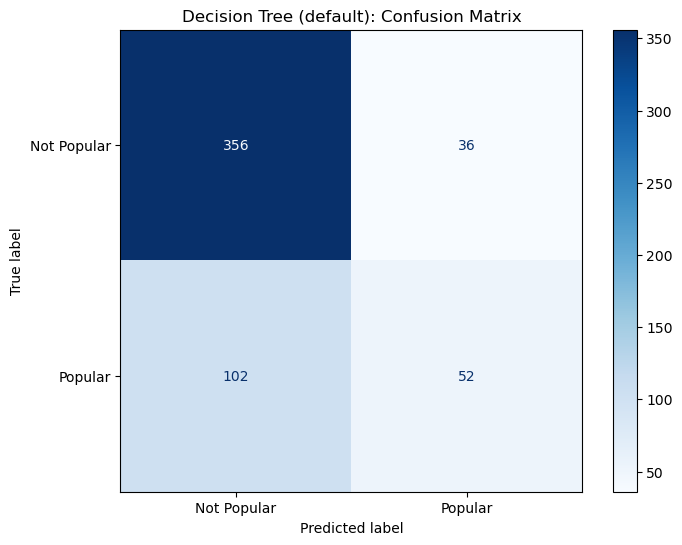

In [207]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    dt_default, X_test_scaled, y_test,
    display_labels=["Not Popular", "Popular"],
    cmap="Blues", ax=ax
)
plt.title("Decision Tree (default): Confusion Matrix")
plt.show()

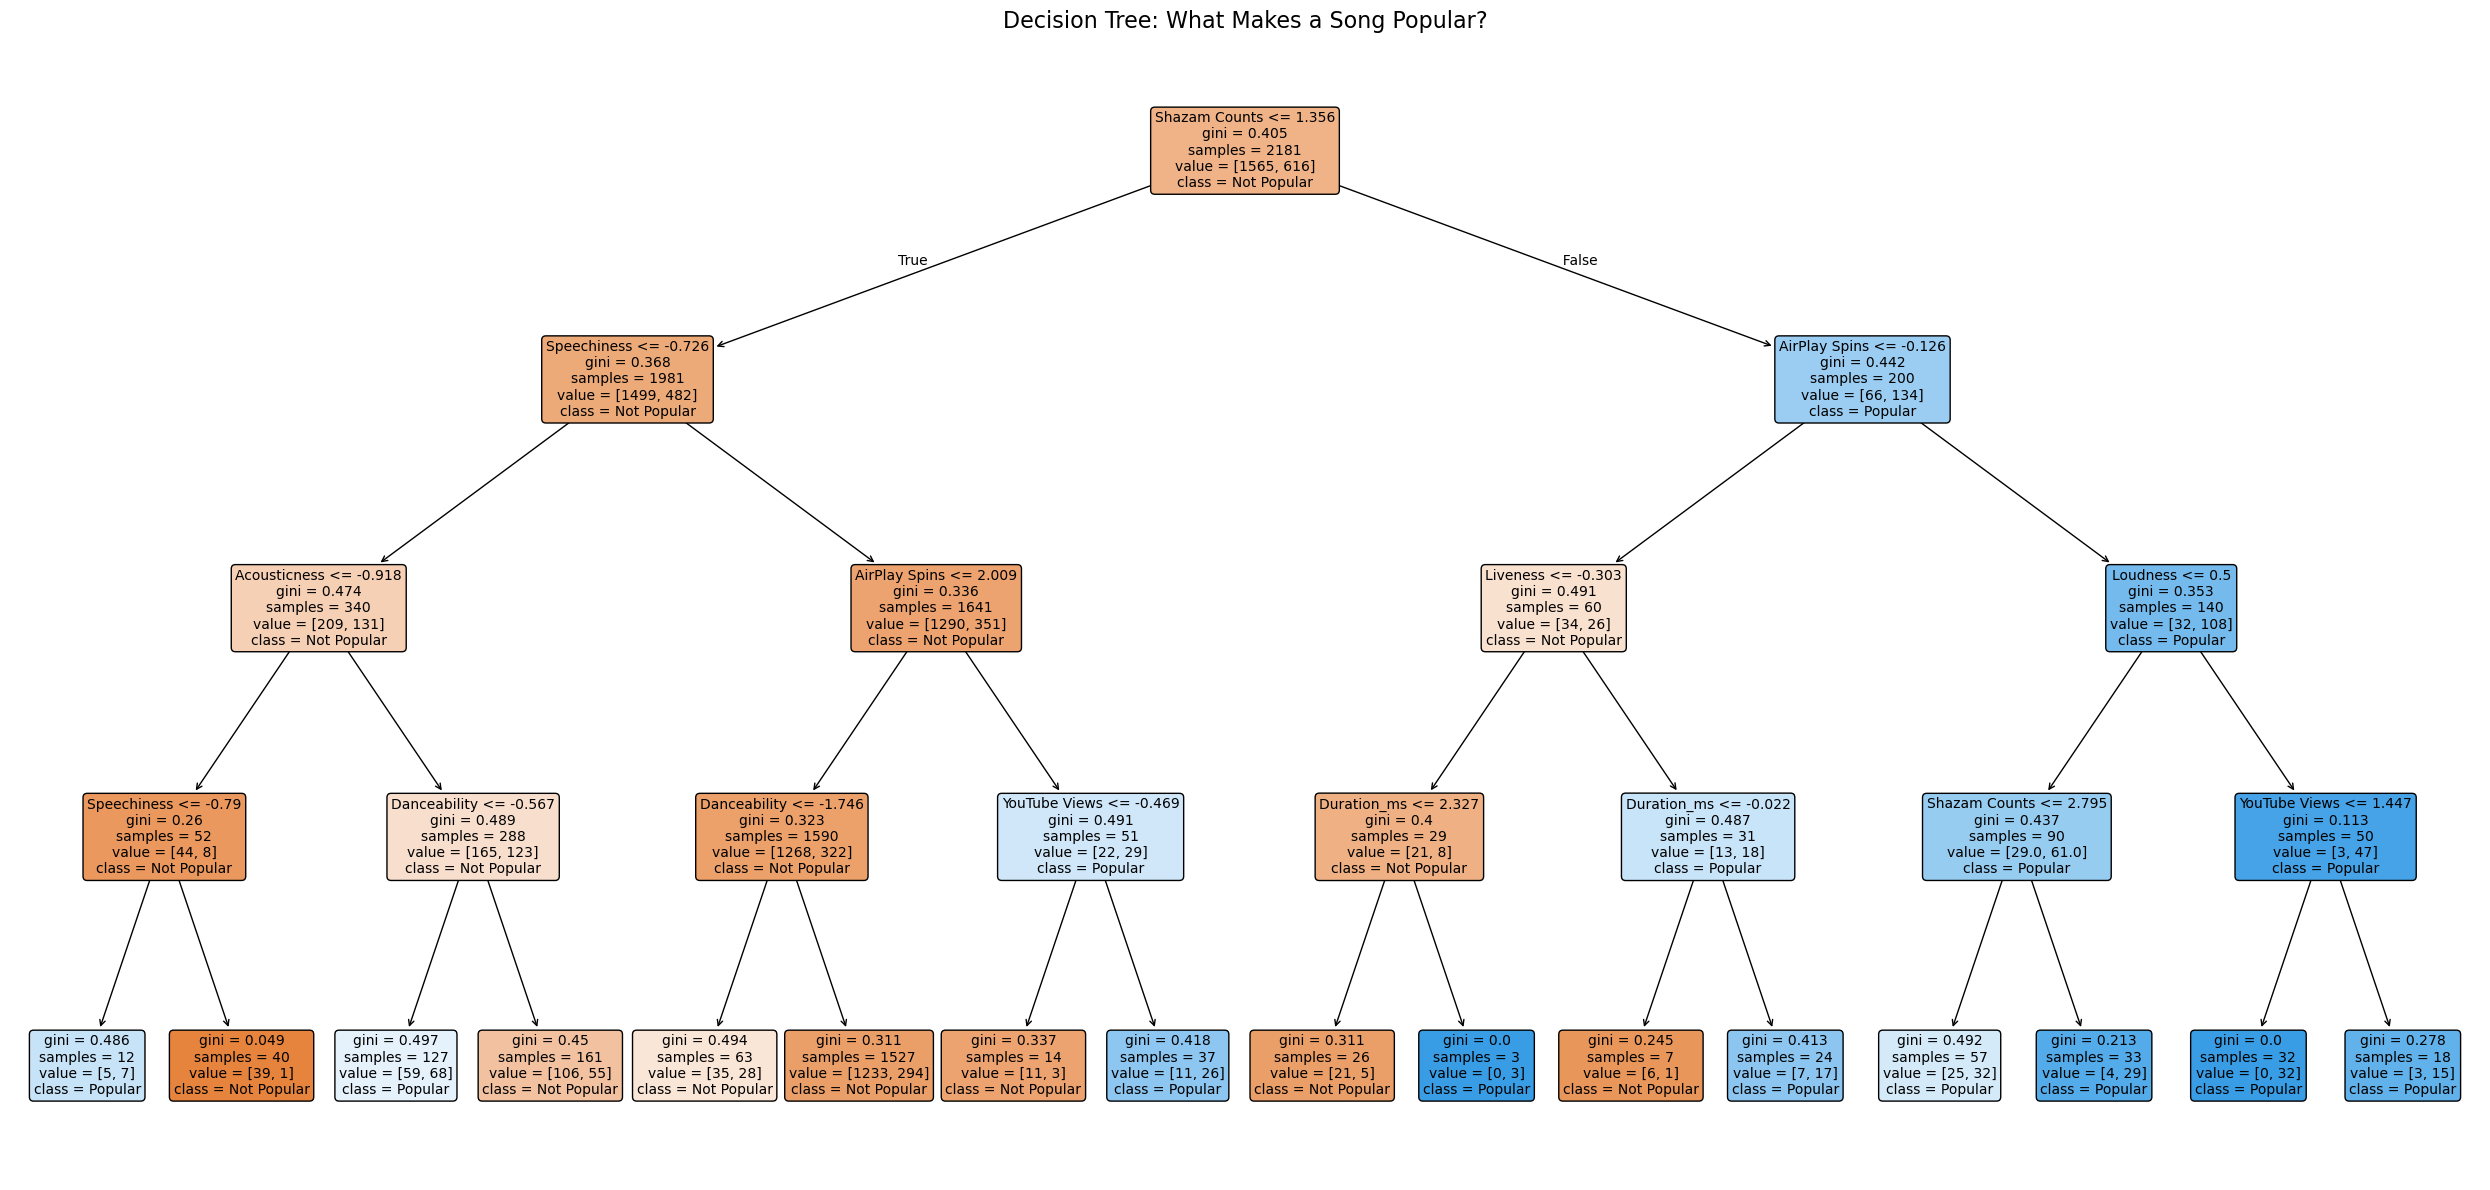

In [208]:
plt.figure(figsize=(25, 12))
plot_tree(
    dt_default,
    feature_names=feature_cols,
    class_names=["Not Popular", "Popular"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree: What Makes a Song Popular?", fontsize=16)
plt.tight_layout()
plt.show()

Breaking Down Your Decision Tree 🎵
What is a decision tree?
It's a model that asks cascading questions (like a game of 20 questions) to classify a song as Popular or Not Popular. At each node, it splits the data based on the most useful feature.

What's inside each box
FieldMeaningcondition (e.g. Shazam Counts <= 1.356)The question asked at this nodeginiNode impurity — 0 = pure (one class only), 0.5 = perfectly mixedsamplesNumber of songs reaching this nodevalue = [X, Y]X = Not Popular songs, Y = Popular songsclassThe majority prediction at this node

How your tree works
🔝 Root — The most important question

Shazam Counts <= 1.356

This is the feature that best separates the data. Out of 2181 songs:

True (left) → 1981 songs — mostly Not Popular
False (right) → 200 songs — mostly Popular

➡️ Key insight: having a high Shazam count is the #1 signal of popularity.

🌿 Left branch (few Shazams → probably Not Popular)
The model refines with:

Speechiness — too much spoken word = less popular
Artist track count — artists with fewer tracks in the dataset
Danceability, Liveness — secondary audio features

🌿 Right branch (many Shazams → probably Popular)
The model refines with:

Danceability <= 0.5 — highly danceable songs stay popular
Artist track count — prolific artists
Energy, Acousticness — sound characteristics


The leaves (final decisions)
The boxes at the very bottom are the final predictions:

🟠 Orange = Not Popular
🔵 Blue = Popular

The purest node in the tree: gini = 0.0, value = [4, 0] → 4 songs, 100% Not Popular, zero mistakes.

Most important features summary
RankFeatureRole1Shazam CountsMain deciding factor2SpeechinessFilters out overly "spoken" tracks3Artist track countEstablished vs emerging artists4DanceabilityBoosts popularity5Energy / AcousticnessFinal fine-tuning

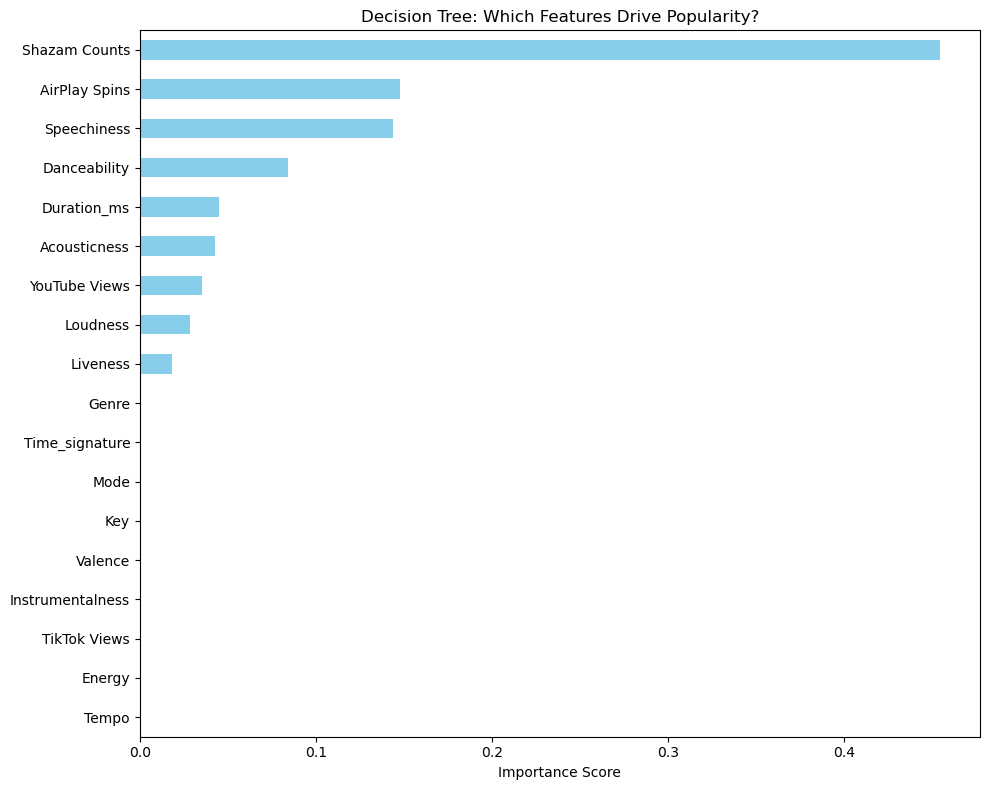


Top 5 most important features:
Shazam Counts    0.454610
AirPlay Spins    0.147636
Speechiness      0.144112
Danceability     0.084082
Duration_ms      0.045069
dtype: float64


In [209]:
importance_dt = pd.Series(
    dt_default.feature_importances_,
    index=feature_cols
).sort_values()

plt.figure(figsize=(10, 8))
importance_dt.plot(kind="barh", color="skyblue")
plt.xlabel("Importance Score")
plt.title("Decision Tree: Which Features Drive Popularity?")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_dt.sort_values(ascending=False).head())

In [210]:
train_acc_dt = accuracy_score(y_train, dt_default.predict(X_train_scaled))
test_acc_dt = accuracy_score(y_test, y_pred_dt_default)

print(f"Train accuracy: {train_acc_dt:.3f}")
print(f"Test accuracy:  {test_acc_dt:.3f}")
print(f"Gap:            {train_acc_dt - test_acc_dt:.3f}")

if train_acc_dt - test_acc_dt > 0.10:
    print("⚠️ Possible overfitting — tuning should help")
else:
    print("✅ No major overfitting")

Train accuracy: 0.770
Test accuracy:  0.747
Gap:            0.023
✅ No major overfitting


In [211]:
param_grid_dt = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_dt.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_dt.best_params_}")
print(f"Best F1 (cross-validated): {grid_dt.best_score_:.3f}")

Best parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best F1 (cross-validated): 0.416


In [212]:
best_dt = grid_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test_scaled)

print("=== DECISION TREE (tuned) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_dt):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best_dt,
                            target_names=["Not Popular", "Popular"]))

# Compare with default
print(f"\n--- Improvement ---")
print(f"Default accuracy: {accuracy_score(y_test, y_pred_dt_default):.3f}")
print(f"Tuned accuracy:   {accuracy_score(y_test, y_pred_best_dt):.3f}")

=== DECISION TREE (tuned) ===
Accuracy: 0.729

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.78      0.88      0.82       392
     Popular       0.53      0.36      0.43       154

    accuracy                           0.73       546
   macro avg       0.65      0.62      0.62       546
weighted avg       0.71      0.73      0.71       546


--- Improvement ---
Default accuracy: 0.747
Tuned accuracy:   0.729


# XG BOOST

In [213]:
xgb_default = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_default.fit(X_train_scaled, y_train)
y_pred_xgb_default = xgb_default.predict(X_test_scaled)

print("=== XGBOOST (default) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_default):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_default,
                            target_names=["Not Popular", "Popular"]))

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:07:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBOOST (default) ===
Accuracy: 0.767

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.77      0.96      0.86       392
     Popular       0.73      0.28      0.40       154

    accuracy                           0.77       546
   macro avg       0.75      0.62      0.63       546
weighted avg       0.76      0.77      0.73       546



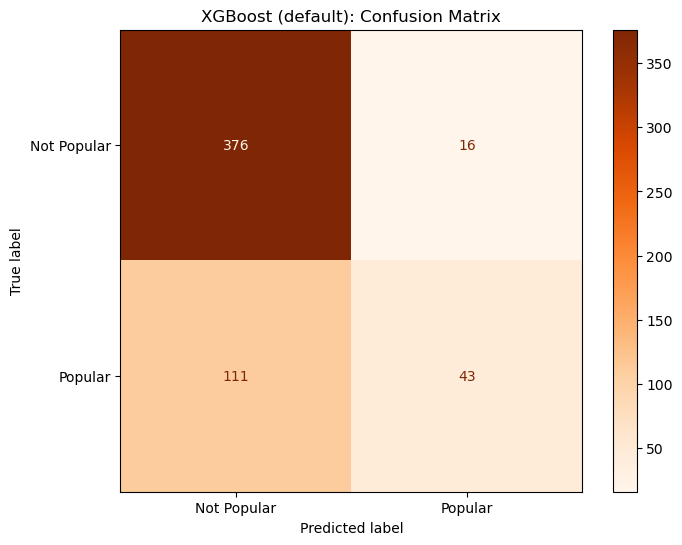

In [214]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    xgb_default, X_test_scaled, y_test,
    display_labels=["Not Popular", "Popular"],
    cmap="Oranges", ax=ax
)
plt.title("XGBoost (default): Confusion Matrix")
plt.show()

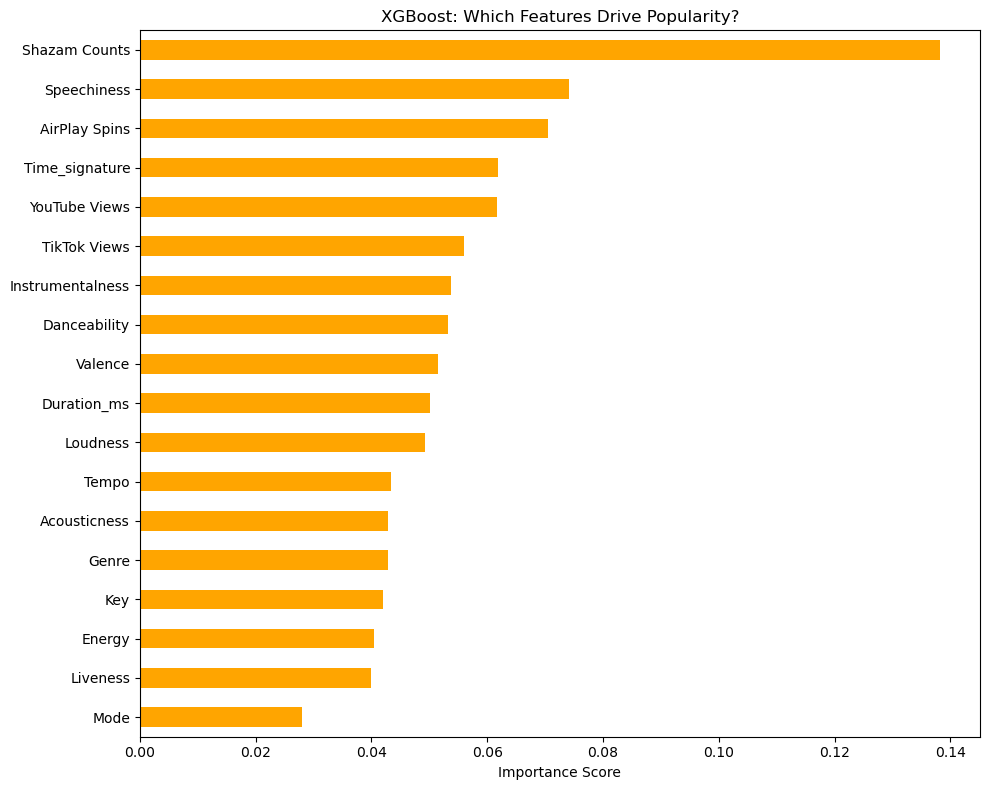


Top 5 most important features:
Shazam Counts     0.138214
Speechiness       0.074184
AirPlay Spins     0.070586
Time_signature    0.061883
YouTube Views     0.061750
dtype: float32


In [215]:
importance_xgb = pd.Series(
    xgb_default.feature_importances_,
    index=feature_cols
).sort_values()

plt.figure(figsize=(10, 8))
importance_xgb.plot(kind="barh", color="orange")
plt.xlabel("Importance Score")
plt.title("XGBoost: Which Features Drive Popularity?")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_xgb.sort_values(ascending=False).head())

In [216]:
train_acc_xgb = accuracy_score(y_train, xgb_default.predict(X_train_scaled))
test_acc_xgb = accuracy_score(y_test, y_pred_xgb_default)

print(f"Train accuracy: {train_acc_xgb:.3f}")
print(f"Test accuracy:  {test_acc_xgb:.3f}")
print(f"Gap:            {train_acc_xgb - test_acc_xgb:.3f}")

if train_acc_xgb - test_acc_xgb > 0.10:
    print("⚠️ Possible overfitting — tuning should help")
else:
    print("✅ No major overfitting")

Train accuracy: 0.873
Test accuracy:  0.767
Gap:            0.105
⚠️ Possible overfitting — tuning should help


In [217]:
param_grid_xgb = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    ),
    param_grid_xgb,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_xgb.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_xgb.best_params_}")
print(f"Best F1 (cross-validated): {grid_xgb.best_score_:.3f}")

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:07:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:07:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:07:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:07:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}
Best F1 (cross-validated): 0.466


In [218]:
best_xgb = grid_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test_scaled)

print("=== XGBOOST (tuned) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_xgb):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best_xgb,
                            target_names=["Not Popular", "Popular"]))

print(f"\n--- Improvement ---")
print(f"Default accuracy: {accuracy_score(y_test, y_pred_xgb_default):.3f}")
print(f"Tuned accuracy:   {accuracy_score(y_test, y_pred_best_xgb):.3f}")

=== XGBOOST (tuned) ===
Accuracy: 0.764

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.78      0.93      0.85       392
     Popular       0.65      0.34      0.45       154

    accuracy                           0.76       546
   macro avg       0.72      0.64      0.65       546
weighted avg       0.75      0.76      0.74       546


--- Improvement ---
Default accuracy: 0.767
Tuned accuracy:   0.764


In [219]:
y_proba = best_xgb.predict_proba(X_test_scaled)

# Show confidence levels
df_predictions = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_best_xgb,
    "confidence": y_proba[:, 1]  # probability of being popular
})

print("Most confident POPULAR predictions:")
print(df_predictions[df_predictions["predicted"] == 1]
      .sort_values("confidence", ascending=False).head(10))

print("\nBorderline predictions (model was unsure):")
print(df_predictions.sort_values("confidence",
      key=lambda x: abs(x - 0.5)).head(10))

Most confident POPULAR predictions:
     actual  predicted  confidence
408       1          1    0.975880
59        1          1    0.966628
116       1          1    0.966046
480       1          1    0.963695
416       1          1    0.963695
1         1          1    0.957993
417       1          1    0.950369
113       1          1    0.947999
207       1          1    0.946965
189       1          1    0.945228

Borderline predictions (model was unsure):
     actual  predicted  confidence
129       0          1    0.501127
187       0          0    0.498042
34        1          0    0.491429
401       0          1    0.510694
433       0          0    0.488722
104       0          1    0.515647
212       0          1    0.516120
362       0          0    0.480468
494       0          0    0.477012
276       1          0    0.476996


# COMPARING ALL DEFAULT MODELS 
Now let's see how the baseline (default hyperparameters) versions of each model performed.

In [221]:
default_models = {
    "KNN": accuracy_score(y_test, y_pred),
    "Decision Tree": accuracy_score(y_test, y_pred_dt_default),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "XGBoost": accuracy_score(y_test, y_pred_xgb_default)
}

print("=" * 50)
print("DEFAULT MODELS COMPARISON")
print("=" * 50)
for model_name, accuracy in sorted(default_models.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:20} → Accuracy: {accuracy:.4f}")
print(f"\nBest default model: {max(default_models, key=default_models.get)}")
print(f"Best accuracy: {max(default_models.values()):.4f}")

DEFAULT MODELS COMPARISON
XGBoost              → Accuracy: 0.7674
Decision Tree        → Accuracy: 0.7473
KNN                  → Accuracy: 0.6557
Random Forest        → Accuracy: 0.6374

Best default model: XGBoost
Best accuracy: 0.7674


# COMPARING ALL TUNED MODELS
Now let's compare the **hyperparameter-tuned** versions using GridSearchCV results.

In [222]:
tuned_models = {
    "KNN (tuned)": accuracy_score(y_test, y_pred_best_knn),
    "Decision Tree (tuned)": accuracy_score(y_test, y_pred_best_dt),
    "Random Forest (tuned)": accuracy_score(y_test, y_pred_best_rf),
    "XGBoost (tuned)": accuracy_score(y_test, y_pred_best_xgb)
}

print("=" * 50)
print("TUNED MODELS COMPARISON")
print("=" * 50)
for model_name, accuracy in sorted(tuned_models.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:25} → Accuracy: {accuracy:.4f}")
print(f"\nBest tuned model: {max(tuned_models, key=tuned_models.get)}")
print(f"Best accuracy: {max(tuned_models.values()):.4f}")

TUNED MODELS COMPARISON
XGBoost (tuned)           → Accuracy: 0.7637
Decision Tree (tuned)     → Accuracy: 0.7289
Random Forest (tuned)     → Accuracy: 0.6190
KNN (tuned)               → Accuracy: 0.5788

Best tuned model: XGBoost (tuned)
Best accuracy: 0.7637


# ENSEMBLE METHOD
An ensemble combines multiple models to make better predictions by combining their votes.
Each tuned model gets one vote, and we use **soft voting** (average of probabilities) for better results.

In [224]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ("knn", best_knn),
        ("dt", best_dt),
        ("rf", best_rf),
        ("xgb", best_xgb)
    ],
    voting="soft"  # soft = average of probability predictions
)

ensemble.fit(X_train_scaled, y_train)
y_pred_ensemble = ensemble.predict(X_test_scaled)

ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
print("=" * 50)
print("ENSEMBLE MODEL")
print("=" * 50)
print(f"Ensemble Accuracy: {ensemble_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble, target_names=["Not Popular", "Popular"]))

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:19:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ENSEMBLE MODEL
Ensemble Accuracy: 0.7637

Classification Report:
              precision    recall  f1-score   support

 Not Popular       0.78      0.93      0.85       392
     Popular       0.66      0.34      0.45       154

    accuracy                           0.76       546
   macro avg       0.72      0.63      0.65       546
weighted avg       0.75      0.76      0.74       546



# FINAL COMPARISON
All models side-by-side: default vs tuned vs ensemble.

In [226]:
all_models = {
    "KNN (default)": default_models["KNN"],
    "KNN (tuned)": tuned_models["KNN (tuned)"],
    "DT (default)": default_models["Decision Tree"],
    "DT (tuned)": tuned_models["Decision Tree (tuned)"],
    "RF (default)": default_models["Random Forest"],
    "RF (tuned)": tuned_models["Random Forest (tuned)"],
    "XGB (default)": default_models["XGBoost"],
    "XGB (tuned)": tuned_models["XGBoost (tuned)"],
    "Ensemble": ensemble_accuracy
}

# Sort by accuracy (best first)
all_models_sorted = dict(sorted(all_models.items(), key=lambda x: x[1], reverse=True))

print("\n" + "=" * 60)
print("FINAL MODEL COMPARISON (ALL MODELS)")
print("=" * 60)
for rank, (model_name, accuracy) in enumerate(all_models_sorted.items(), 1):
    print(f"{rank:2}. {model_name:25} → {accuracy:.4f}")

best_model_name = list(all_models_sorted.keys())[0]
best_model_acc = list(all_models_sorted.values())[0]
print(f"\n🏆 BEST MODEL: {best_model_name} (Accuracy: {best_model_acc:.4f})")


FINAL MODEL COMPARISON (ALL MODELS)
 1. XGB (default)             → 0.7674
 2. XGB (tuned)               → 0.7637
 3. Ensemble                  → 0.7637
 4. DT (default)              → 0.7473
 5. DT (tuned)                → 0.7289
 6. KNN (default)             → 0.6557
 7. RF (default)              → 0.6374
 8. RF (tuned)                → 0.6190
 9. KNN (tuned)               → 0.5788

🏆 BEST MODEL: XGB (default) (Accuracy: 0.7674)


# FEATURE IMPORTANCE ACROSS ALL MODELS
Compare which features the tree-based models (Decision Tree, Random Forest, XGBoost) consider most important.
Do they all agree? Or do they have different perspectives?

In [227]:
# Extract feature importance from the best models
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "DT (tuned)": best_dt.feature_importances_,
    "RF (tuned)": best_rf.feature_importances_,
    "XGB (tuned)": best_xgb.feature_importances_
})
 
# Calculate average importance across all three models
importance_df["Average Importance"] = importance_df[["DT (tuned)", "RF (tuned)", "XGB (tuned)"]].mean(axis=1)
importance_df = importance_df.sort_values("Average Importance", ascending=False)
 
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE COMPARISON")
print("=" * 80)
print(importance_df.to_string(index=False))
 
print(f"\n\nTop 5 Most Important Features (by average):")
for i, row in importance_df.head(5).iterrows():
    print(f"  {row['Feature']:25} → {row['Average Importance']:.4f}")


FEATURE IMPORTANCE COMPARISON
         Feature  DT (tuned)  RF (tuned)  XGB (tuned)  Average Importance
   Shazam Counts    0.281939    0.119012     0.100003            0.166985
     Speechiness    0.130000    0.077266     0.061131            0.089466
   AirPlay Spins    0.091814    0.088343     0.064551            0.081569
   YouTube Views    0.091572    0.071591     0.055183            0.072782
    Danceability    0.077509    0.068830     0.052814            0.066384
    Acousticness    0.063496    0.059181     0.048160            0.056945
    TikTok Views    0.039706    0.069450     0.052196            0.053784
        Liveness    0.059872    0.054256     0.043100            0.052409
         Valence    0.029296    0.061685     0.046836            0.045939
     Duration_ms    0.031614    0.060292     0.043702            0.045203
        Loudness    0.032642    0.056609     0.044005            0.044419
           Tempo    0.026721    0.057287     0.044137            0.042715
  Time_

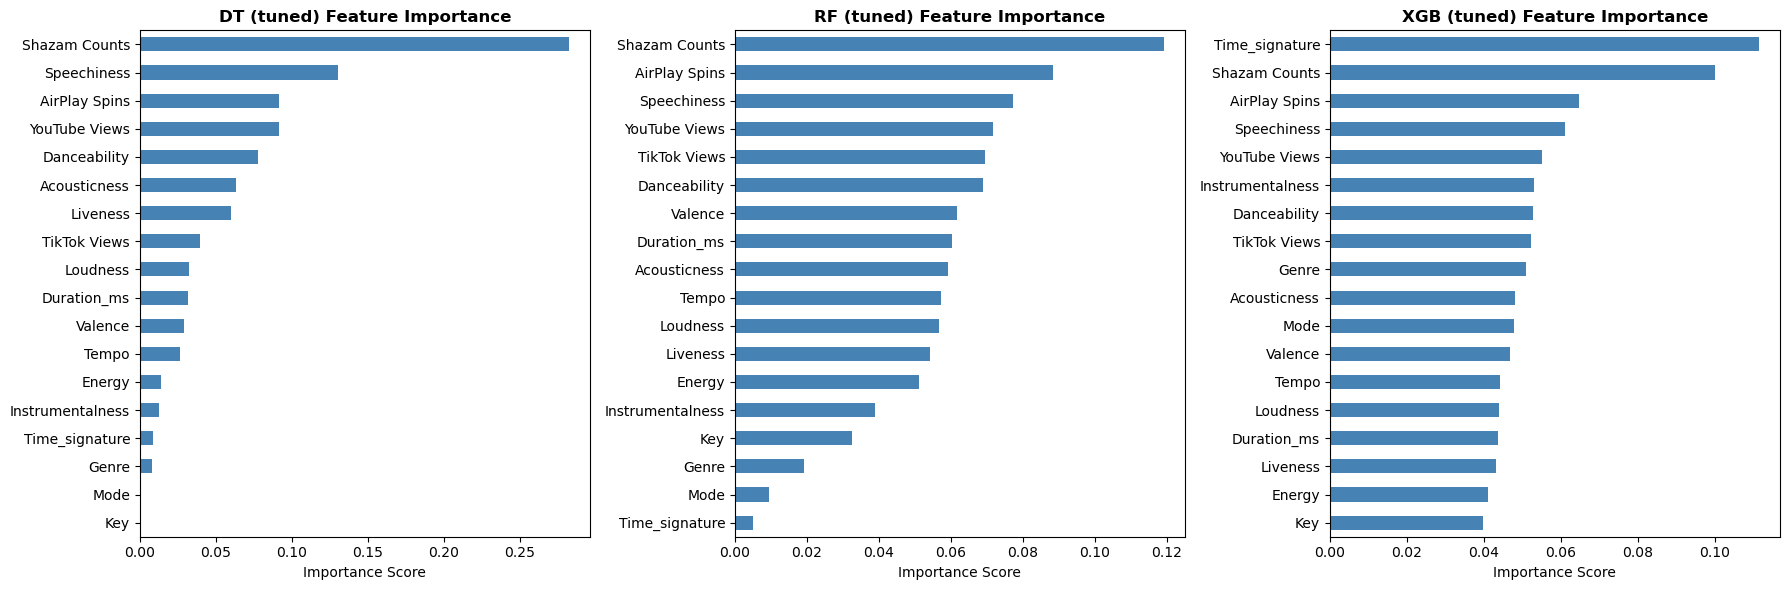


✅ All three tree-based models plotted side-by-side!


In [228]:
# Side-by-side bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
 
models_to_plot = [
    ("DT (tuned)", best_dt, axes[0]),
    ("RF (tuned)", best_rf, axes[1]),
    ("XGB (tuned)", best_xgb, axes[2])
]
 
for model_name, model, ax in models_to_plot:
    importances = pd.Series(
        model.feature_importances_,
        index=feature_cols
    ).sort_values()
    
    importances.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"{model_name} Feature Importance", fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance Score")
 
plt.tight_layout()
plt.show()
 
print("\n✅ All three tree-based models plotted side-by-side!")

# CONSLUSIONS
## Summary of Results

In [230]:
print("\n" + "=" * 80)
print("CONCLUSIONS")
print("=" * 80)
 
# 1. Which model performed best?
print(f"\n1️⃣  BEST MODEL")
print(f"   Winner: {best_model_name}")
print(f"   Accuracy: {best_model_acc:.2%}")
 
# 2. Did tuning improve results?
print(f"\n2️⃣  DID HYPERPARAMETER TUNING HELP?")
for model_type in ["KNN", "Decision Tree", "Random Forest", "XGBoost"]:
    if model_type == "KNN":
        default_acc = default_models["KNN"]
        tuned_acc = tuned_models["KNN (tuned)"]
    elif model_type == "Decision Tree":
        default_acc = default_models["Decision Tree"]
        tuned_acc = tuned_models["Decision Tree (tuned)"]
    elif model_type == "Random Forest":
        default_acc = default_models["Random Forest"]
        tuned_acc = tuned_models["Random Forest (tuned)"]
    else:  # XGBoost
        default_acc = default_models["XGBoost"]
        tuned_acc = tuned_models["XGBoost (tuned)"]
    
    improvement = tuned_acc - default_acc
    direction = "✅ Improved" if improvement > 0 else "❌ Decreased" if improvement < 0 else "➡️  No change"
    print(f"   {model_type:20} {direction:15} ({improvement:+.4f})")
 
# 3. Did the ensemble beat individual models?
print(f"\n3️⃣  ENSEMBLE VS INDIVIDUAL MODELS")
print(f"   Ensemble Accuracy:    {ensemble_accuracy:.4f}")
best_individual = max(tuned_models.values())
print(f"   Best Individual Model: {max(tuned_models.values()):.4f}")
ensemble_advantage = ensemble_accuracy - best_individual
if ensemble_advantage > 0:
    print(f"   Result: Ensemble won! 🎉 (+{ensemble_advantage:.4f})")
else:
    print(f"   Result: Individual model was better ({ensemble_advantage:.4f})")
 
# 4. Which features drive popularity the most?
print(f"\n4️⃣  TOP FEATURES THAT DRIVE POPULARITY")
for rank, (idx, row) in enumerate(importance_df.head(5).iterrows(), 1):
    print(f"   {rank}. {row['Feature']:25} (importance: {row['Average Importance']:.4f})")
 
print(f"\n" + "=" * 80)
print("✅ MODELING COMPLETE!")
print("=" * 80)


CONCLUSIONS

1️⃣  BEST MODEL
   Winner: XGB (default)
   Accuracy: 76.74%

2️⃣  DID HYPERPARAMETER TUNING HELP?
   KNN                  ❌ Decreased     (-0.0769)
   Decision Tree        ❌ Decreased     (-0.0183)
   Random Forest        ❌ Decreased     (-0.0183)
   XGBoost              ❌ Decreased     (-0.0037)

3️⃣  ENSEMBLE VS INDIVIDUAL MODELS
   Ensemble Accuracy:    0.7637
   Best Individual Model: 0.7637
   Result: Individual model was better (0.0000)

4️⃣  TOP FEATURES THAT DRIVE POPULARITY
   1. Shazam Counts             (importance: 0.1670)
   2. Speechiness               (importance: 0.0895)
   3. AirPlay Spins             (importance: 0.0816)
   4. YouTube Views             (importance: 0.0728)
   5. Danceability              (importance: 0.0664)

✅ MODELING COMPLETE!
